# HDT 2: Probabilidad, MLE y MAP

**Ciencia de Datos, Sección A** · Asignada: jueves 6 de agosto · **Entrega: jueves 13 de agosto, 23:59**

**Nombre:** _Victor Saravia_
**Carné no.** _20240060_

Completar las celdas marcadas con `# ¿Qué va aquí?`. Cada ejercicio incluye una verificación comentada: descomentar para comprobar el resultado. Antes de entregar: **Kernel → Restart & Run All** (un notebook que no corre de arriba a abajo pierde 0.5 pts).

AI: resolver sin AI. Si se usó para entender un concepto, anotarlo en la mini-bitácora del final.

## Setup

Dependencias: `pip install numpy pandas matplotlib requests`. El rango de fechas es fijo (1 de mayo al 31 de julio de 2026): todos trabajan con los mismos 92 días y las verificaciones son exactas.

In [2]:
import json
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

AZUL, ROJO, GRIS, LINEA = "#3A6EA5", "#B04A2E", "#75808E", "#E0E4EA"

def eje_limpio(ax):
    ax.grid(color=LINEA, lw=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

URL = "https://archive-api.open-meteo.com/v1/archive"

## Parte A · Adquirir los datos (0.6 pt)

Clima observado de Ciudad de Guatemala (14.63, -90.51), del **2026-05-01** al **2026-07-31**, con las variables diarias `temperature_2m_max` y `precipitation_sum`, zona horaria `America/Guatemala`.

### Ejercicio 1 (0.15): descargar de la API

Armar el diccionario `params` con latitud, longitud, fechas, variables diarias (las dos en una sola cadena separada por coma) y zona horaria. Hacer el request y validar.

In [7]:
params = {
    "latitude": 14.63,
    "longitude": -90.51,
    "start_date": "2026-05-01",
    "end_date": "2026-07-31",
    "daily": "temperature_2m_max,precipitation_sum",
    "timezone": "America/Guatemala"
    # ¿Qué va aquí? latitude, longitude, start_date, end_date,
    # daily (dos variables separadas por coma), timezone
}

r = requests.get(URL, params=params, timeout=20)
print(r.status_code)
datos = r.json()

# Verificación (descomentar):
assert r.status_code == 200
assert list(datos["daily"].keys()) == ["time", "temperature_2m_max", "precipitation_sum"]

200


### Ejercicio 2 (0.15): JSON a DataFrame

Crear `clima` a partir de `datos["daily"]` y convertir la columna `time` a datetime.

In [6]:
clima = pd.DataFrame(datos["daily"]) # ¿Qué va aquí?

# convertir time a datetime
clima["time"] = pd.to_datetime(clima["time"])

clima.head()
print(clima.head())  

# Verificación (descomentar):
assert clima.shape == (92, 3)
assert clima.isna().sum().sum() == 0
assert str(clima["time"].dtype).startswith("datetime")

        time  temperature_2m_max  precipitation_sum
0 2026-05-01                29.6                0.0
1 2026-05-02                31.1                0.2
2 2026-05-03                28.2                0.9
3 2026-05-04                28.6                0.8
4 2026-05-05                30.9                1.6


### Ejercicio 3 (0.15): días con lluvia

(a) Columna booleana `llovio`: lluvia **mayor a 1.0 mm** (estricto). (b) `k` = días con lluvia y `n` = total de días. (c) El día con la lluvia máxima: fecha y milímetros.

In [11]:
# ¿Qué va aquí?
clima["llovio"] = clima["precipitation_sum"] > 1.0 # TRUE cuando la lluvia es más que 1 mm

k = int(clima["llovio"].sum()) # Cantidad de días con lluvia
n = len(clima) # Total de días

dia_max = clima["precipitation_sum"].idxmax() # Indice del día con más lluvia
fecha_max = clima.loc[dia_max, "time"] # Fecha del día con más lluvia
lluvia_max = clima.loc[dia_max, "precipitation_sum"] # Cantidad de lluvia máxima

print("Días con lluvia (k):", k)
print("Total de días (n):", n)
print("Día que más llovió y mm:", fecha_max.strftime("%Y-%m-%d"), lluvia_max, "mm")

# Verificación (descomentar):
assert int(clima["llovio"].sum()) == 51 and len(clima) == 92

Días con lluvia (k): 51
Total de días (n): 92
Día que más llovió y mm: 2026-06-22 27.7 mm


### Ejercicio 4 (0.15): ficha de procedencia

Construir el diccionario `ficha` con las llaves `fuente`, `url`, `rango_fechas`, `fecha_descarga`, `filas` y `variables`. Guardarlo como `clima_procedencia.json` y guardar `clima` como `clima_gt.csv`.

In [12]:
ficha = {
    "fuente": "Historical Weather API from Open Meteo",
    "url": URL,
    "rango_fechas": [params["start_date"], params["end_date"]],
    "fecha_descarga": pd.Timestamp.now(tz=params["timezone"]).strftime("%Y-%m-%d"),
    "filas": len(clima),
    "variables": ["temperature_2m_max","precipitation_sum"]
}

# guardar ficha como clima_procedencia.json y clima como clima_gt.csv
with open("clima_procedencia.json", "w", encoding="utf-8") as archivo:
    json.dump(ficha, archivo, ensure_ascii=False, indent=4)

clima.to_csv("clima_gt.csv", index=False)


# Verificación (descomentar):
import os
assert os.path.exists("clima_procedencia.json") and os.path.exists("clima_gt.csv")
assert ficha["filas"] == 92

## Parte B · Estimar (1.2 pt)

Los datos ya están en memoria. Ahora la pregunta de la sesión 5: ¿qué parámetros hacen estos datos más plausibles?

### Ejercicio 5 (0.20): MLE de Bernoulli

Cada día es un ensayo Bernoulli: llueve o no. (a) `p_hat`, el MLE en una línea. (b) La función `log_lik` (vectorizada sobre `p`). (c) `p_grilla`: el argmax de `log_lik` sobre la grilla. Deben coincidir.

In [24]:
p_hat = k/n   # ¿Qué va aquí? el MLE en una línea

def log_lik(p, k, n):
    return k * np.log(p) + (n - k) * np.log(1 - p) 
    pass

grilla = np.linspace(0.001, 0.999, 999)

ll = log_lik(grilla, k, n) # Este es el log-likelihood evaluado en la grilla
p_grilla = grilla[np.argmax(ll)] # El valor que maximiza el log-likelihood en grilla

print("MLE:", p_hat)
print("MLE con grilla:", p_grilla)

# Verificación (descomentar):
assert abs(p_hat - k / n) < 1e-12
assert abs(p_grilla - p_hat) < 0.001

MLE: 0.5543478260869565
MLE con grilla: 0.554


### Ejercicio 6 (0.20): graficar la log-verosimilitud

Graficar `log_lik` sobre la grilla y marcar el máximo (línea vertical o anotación). El patrón está en el notebook de la sesión 5.

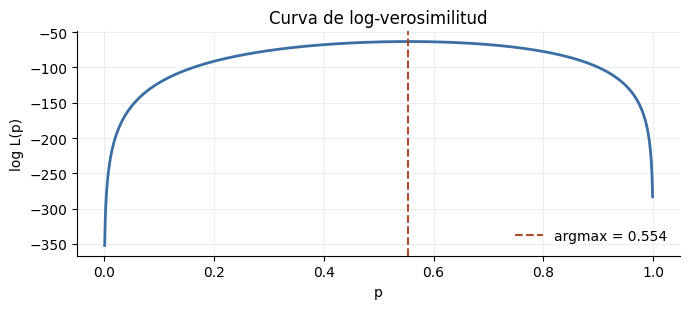

In [40]:
fig, ax = plt.subplots(figsize=(7, 3.2))

# Calcular la log-verosimilitud para cada valor de la grilla
valores = log_lik(grilla, k, n)
ax.plot(grilla, valores, color=AZUL, lw=2)

# Marcar el valor donde la curva alcanza su máximo
ax.axvline(
    p_grilla,
    color=ROJO,
    ls="--",
    lw=1.5,
    label=f"argmax = {p_grilla:.3f}"
)

ax.set_xlabel("p")
ax.set_ylabel("log L(p)")
ax.set_title("Curva de log-verosimilitud")
ax.legend(frameon=False)
eje_limpio(ax)
plt.tight_layout()
plt.show()

### Ejercicio 7 (0.20): MLE de la Normal

Sobre `temperature_2m_max`: (a) `mu_hat` sin usar `.mean()`. (b) `sigma2_hat`, el promedio de las desviaciones al cuadrado. Comparar con NumPy.

In [ ]:
temp = clima["temperature_2m_max"]

# a) mu_hat: el promedio, sin usar .mean()
mu_hat = np.sum(temp) / len(temp)

# b) sigma2_hat: promedio de (temp - mu_hat)**2
sigma2_hat = np.sum((temp - mu_hat) ** 2) / len(temp)

print("mu_hat:", mu_hat)
print("mu_hat con NumPy:", temp.mean())
print("sigma_hat:", np.sqrt(sigma2_hat))
print("con NumPy:", temp.std(ddof=0)) # ddof=0 para la desviación estándar poblacional

# Verificación (descomentar):
assert np.isclose(mu_hat, temp.mean())
assert np.isclose(np.sqrt(sigma2_hat), temp.std(ddof=0))

mu_hat: 26.85978260869566
mu_hat con NumPy: 26.85978260869566
sigma_hat: 1.9041179506880148
con NumPy: 1.9041179506880148


### Ejercicio 8 (0.20): MAP con un prior equivocado

Prior Beta(2, 10): la creencia de alguien que piensa que en Guatemala casi no llueve (1 día de lluvia en 10 imaginarios). Implementar `map_beta` y comparar con el MLE usando los 92 días.

$$\hat{p}_{MAP} = \frac{k + \alpha - 1}{n + \alpha + \beta - 2}$$

In [ ]:
def map_beta(k, n, a=2, b=10):
    return (k + a - 1) / (n + a + b - 2)
    pass

# comparar MLE y MAP con los 92 días
p_map = map_beta(k, n)

print(f"MLE: {p_hat:.3f}", f"y MAP: {p_map:.3f}") # 3f 
print(f"Diferencia: {abs(p_hat - p_map):.3f}")

# Verificación (descomentar):
assert round(map_beta(k, n), 3) == 0.510

MLE: 0.554 y MAP: 0.510
Diferencia: 0.045


### Ejercicio 9 (0.20): el prior se diluye

Para cada `m` en `[7, 14, 30, 60, 92]`: con los **primeros** `m` días, calcular `k_m`, el MLE, el MAP y la diferencia absoluta. Guardar `(m, mle_m, map_m)` en `resultados` e imprimir la tabla.

In [41]:
ns = [7, 14, 30, 60, 92]
resultados = []

for m in ns:
    k_m = int(clima["llovio"][:m].sum())

    # Calcular MLE y MAP
    mle_m = k_m / m
    map_m = map_beta(k_m, m)

    # Calcular la diferencia entre ambos
    diferencia = abs(mle_m - map_m)

    # Guardar 
    resultados.append((m, mle_m, map_m))

    print(m,k_m, round(mle_m, 3), round(map_m, 3), round(diferencia, 3), sep="\t")
    
    pass

# Verificación (descomentar):
difs = [abs(mle_m - map_m) for _, mle_m, map_m in resultados]
assert round(difs[0], 2) == 0.19 and round(difs[-1], 2) == 0.04

7	3	0.429	0.235	0.193
14	4	0.286	0.208	0.077
30	14	0.467	0.375	0.092
60	38	0.633	0.557	0.076
92	51	0.554	0.51	0.045


### Ejercicio 10 (0.20): graficar la dilución

Con `resultados`: graficar MLE y MAP contra `m` (dos series con leyenda). El patrón está en el notebook de la sesión 5.

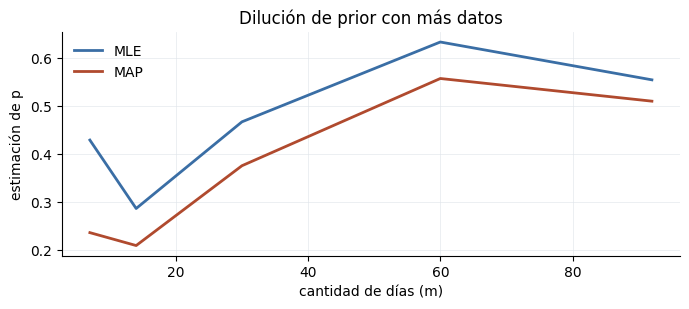

In [43]:
# Separar los valores en resultados para graficar
m_valores = [fila[0] for fila in resultados]
mle_valores = [fila[1] for fila in resultados]
map_valores = [fila[2] for fila in resultados]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(
    m_valores,
    mle_valores,
    color=AZUL,
    lw=2,
    label="MLE"
)
ax.plot(
    m_valores,
    map_valores,
    color=ROJO,
    lw=2,
    label="MAP"
)
ax.set_xlabel("cantidad de días (m)")
ax.set_ylabel("estimación de p")
ax.set_title("Dilución de prior con más datos")
ax.legend(frameon=False)
eje_limpio(ax)
plt.tight_layout()
plt.show()

## Parte C · Criterio (0.2 pt)

### Ejercicio 11 (0.20)

El prior Beta(2,10) era objetivamente malo para época lluviosa. En 3-4 líneas, **citando los números del ejercicio 9**: ¿qué hicieron los datos con ese prior, a partir de cuántos días dejó de dominar, y qué implica esto para usar regularización (ridge/lasso) en modelos con pocos datos?

_(Responder editando esta celda)_

**Respuesta:** ...

## Mini-bitácora de AI (opcional, no penaliza)

Si se usó AI para entender algún concepto, anotar aquí qué se preguntó y qué se entendió. Si no se usó, escribir "No se usó".

- ...